# Text-Segmentierung Klassifkationsmodell

Training und Test eines Klassifikationsodells zur Text-Segmentierung mittels maschinellen Lernens und Verwendung baumbasierter Verfahren wie Random-Forest, LGBM oder XGBoost.

**Voraussetzungen**

Environment: model

Zur Erstellung des Datensatzes für das Training muss für die verwendeten PDF-Dokumente zurvor die Vorverarbeitung und Erstellung der Dataframes über das Notebook Preparation.ipynb ausgeführt werden.

**Versuchsaufbau**

Für das Training der Modelle werden die Dokumente verwendet, auf welche sich keine der gewählten Fragen für die Generierung der Antworten durch die Sprachmodelle beziehen. Der Datensatz wird aus den Merkmalen der einzelnen Blöcke und deren jeweils folgenden Block erstellt.

| Merkmal | Datentyp | Bedeutung |
| - | - | - |
| text_len | int | Anzahl Zeichen des Blocks |
| word_count | int | Anzahl Wörter des Blocks, unterteilt nach Leerzeichen |
| word_distinct_count_ratio | float | Verhältnis eindeutiger Wörter/Gesamtzahl |
| embedding_vektor | list[float] | Embedding-Vektor des Blocks |

Das Training und der Test der Klassifikationsmodelle unter Verwendung der baumbasierten Verfahren sowie der Neuronalen Netzwerke erfolgt mit dem gleichen Datensatz.

Bedingt durch den geringen Umfang der zur Verfügung stehenden Ressource und des Umfangs des Datensatzes (Anzahl Sample+Merkmale), wird Tests nur eine Teilmenge/Stichprobe der zur Verfügung stehenden Daten verwendet.

## Setup

### Pakete laden

In [1]:
import config

import time

import regex as re

import pandas as pd
import numpy as np

from openai import OpenAI

# Scikit learn
#from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix, recall_score

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# Optimization
from skopt import BayesSearchCV
from skopt.space import Integer, Categorical, Real

from util.datasetprocessor import DatasetProcessor
from util.pdfprocessor import PDFProcessor
from util.px import PX
from util.helper import Helper

# Plot
import plotly.express as px
import plotly.graph_objects as go

### Variablen+Funktionen

In [2]:
# Klassen-Label
labels = ['false', 'true']

In [3]:
# Funktion zur Darstellung der Ergebnisse der Hyperparameter-Optimierung
def displayHPOResults(search_result):
    results = pd.DataFrame(search_result.cv_results_)
    iterations = np.arange(1, len(results) + 1)
    mean_test_scores = results['mean_test_score'].values
    best_so_far = np.maximum.accumulate(mean_test_scores)
    
    fig = go.Figure()
    
    fig.add_trace(go.Scatter(
        x=iterations, 
        y=mean_test_scores, 
        mode='lines+markers',
        name='mean_test_score',
        #text='mean_test_score',
        #text=[f'{s:.4f}' for s in results['mean_test_score']]
    ))
    
    fig.add_trace(
        go.Scatter(#x=iterations, 
        y=best_so_far,
        name='best_so_far',
    ))
    
    fig.show()

### Daten laden

In [4]:
# Answers
answers = pd.read_json(f'{config.dataset["path"]}answers.json', orient='index', dtype_backend='numpy_nullable').rename(columns={0: "answer"})
# Queries
queries = pd.read_json(f'{config.dataset["path"]}queries.json', orient='index', dtype_backend='numpy_nullable')
# Relations
qrels = pd.read_json(f'{config.dataset["path"]}qrels.json', orient='index', dtype_backend='numpy_nullable')
# PDF URLs
#pdf_urls = pd.read_json(f'{config.dataset["path"]}pdf_urls.json', orient='index', dtype_backend='numpy_nullable').rename(columns={0: "pdf_urls"})

In [5]:
pdf_urls_clean = pd.read_json(f'{config.dataset["path"]}pdf_urls_clean.json', orient='index', dtype_backend='numpy_nullable')#.rename(columns={0: "pdf_urls"})
pdf_urls = pdf_urls_clean.loc[pdf_urls_clean.values]

### Fragen selektieren

Fragen mit Quelle "Text" und "Text-Tabelle" und mindestens acht Wörtern in der Referenz-Antwort (Fragen mit kurzen Antworten wie "yes" ausschließen) für Ausführung selektieren

In [6]:
# Fragen und Antworten über Index joinen
queries_answers = queries.merge(answers, how='inner', left_index=True, right_index=True)

# Anzahl Wörter der Fragen 
queries_answers['answer_replace'] = queries_answers['answer'].str.replace(r'\p{P}+', '', regex=True).str.replace(r'[\n\t\s]+', ' ', regex=True)
queries_answers['answer_word_count'] = queries_answers['answer_replace'].str.split(' ').str.len()

# Fragen mit source=text|text-table und answer_word_count>=8
queries_text_text_table = queries_answers.loc[((queries_answers['source'] == 'text') | (queries_answers['source'] == 'text-table')) & (queries_answers['answer_word_count'] >= 8)]

# 1/4 der Fragen selektieren
queries_text_text_table = queries_text_text_table.sample(n=round(queries_text_text_table.shape[0] / 4), axis=0, random_state=42)

In [7]:
#queries_text_text_table

Anzahl bereinigter Dokumente, auf welche sich keine der gewählten Fragen beziehen.

In [8]:
# Anzahl Fragen source=text|text-table und answer_word_count>=8

#print(queries_text_text_table.sample(n=round(queries_text_text_table.shape[0] / 4), axis=0, random_state=42).shape[0])
#430

In [9]:
# Anzahl Dokumente, auf die sich die gewählten Fragen beziehen

#print(qrels.loc[queries_text_text_table.sample(n=round(queries_text_text_table.shape[0] / 4), axis=0, random_state=42).index]['doc_id'].unique().shape[0])
#266

In [10]:
# Anzahl gewählter Dokumente, welche aus Datensatz entfernt wurden

#qrels_select = qrels.loc[queries_text_text_table.sample(n=round(queries_text_text_table.shape[0] / 4), axis=0, random_state=42).index]
#print(qrels_select.loc[~qrels_select['doc_id'].isin(pdf_urls.index)]['doc_id'].unique().shape[0])
# 21

In [11]:
# Beireinigte Dokumente, auf welche sich die gewählten Fragen beziehen

#qrels_select = qrels.loc[queries_text_text_table.sample(n=round(queries_text_text_table.shape[0] / 4), axis=0, random_state=42).index]
#qrels_select = qrels_select.drop(qrels_select.loc[~qrels_select['doc_id'].isin(pdf_urls.index)].index)
#print(pdf_urls.loc[qrels_select['doc_id'].unique()].shape[0])
#245

In [12]:
# Dokumente, welche sich nicht auf die gewählten Fragen beziehen

#qrels_select = qrels.loc[queries_text_text_table.sample(n=round(queries_text_text_table.shape[0] / 4), axis=0, random_state=42).index]
#qrels_select = qrels_select.drop(qrels_select.loc[~qrels_select['doc_id'].isin(pdf_urls.index)].index)

#print(pdf_urls.loc[~pdf_urls.index.isin(qrels_select['doc_id'].unique())].shape[0])
#622

### Dokumente selektieren

Die gewählten 430 Fragen beziehen sich auf 266 Dokumente. 33 der Fragen beziehen sich auf 21 Dokumente, die im Zuge der Bereinigung ausgeschlossen wurden. Für die Vorhersage werden die 245 verbleibenden Dokumente und für das Training der Modelle die 622 der insgesamt 867 bereinigten Dokumente.

Als Dimension für die Embedding-Vektoren wird 768 verwendet und die Werte als 16 Bit Floats (halbe Präzision) im Speicher abgelegt.

In [7]:
# Beziehung zwischen Frage und Dokument über qrels
# qrels/Dokumente für alle Fragen wählen
qrels_select = qrels.loc[queries_text_text_table.index]
# qrels ausschließen, für die Dokumente (doc_id) nicht in pdf_urls (index)
qrels_select = qrels_select.drop(qrels_select.loc[~qrels_select['doc_id'].isin(pdf_urls.index)].index)

pdf_urls_select = pdf_urls.loc[~pdf_urls.index.isin(qrels_select['doc_id'].unique())]

### Datensatz erstellen

In [8]:
df = DatasetProcessor.dataset_create(
    config.dataset['path'], 
    pdf_urls_select.sample(n=1, axis=0, random_state=42),
    embedding_dimension=768,
)#.sample(frac=1, axis=0, random_state=42)

2404.11222v2


### Pipeline erstellen

Pipeline für Preprocessing der Daten (Transformer) und Modell-Training erstellen.

### Preprocessing

Pipeline für Daten-Preprocessing erstellen.

Der verwendete Datensatz beinhaltet ausschließlich nummerische und keine kategorialen oder ordinalen Merkmale.

#### Feature-Typen wählen

Unterteilung der Merkmale nach (Daten)Typ für Behandlung (Skalierung numerischer Werte oder Encoding kategorialer-/ordinaler Werte) durch Transformer innerhalb der Sklearn-Pipeline.

In [9]:
#numeric_features = ['text_len', 'text_distinct_word_ratio', 'text_len_next', 'text_distinct_word_ratio_next']
numeric_features = df.drop(columns=['boundary']).columns.tolist()

#### Transformer

Transformer mit spezifischen Funktionen (Scaling, Encoding) für numerische, kategoriale und ordinale Merkmale erzeugen.

Zur Skalierung der nummerischen Merkmale wurden in einem Test mit dem RobustScaler die besten Ergebnisse erzielt.

In [10]:
numeric_transformer = Pipeline(steps=[
    # keine Durchführung von Imputation
    #('imputer', SimpleImputer(strategy='median')),#constant #mean
    # Werte skalieren
    ('scaler', RobustScaler())#StandardScaler, MinMaxScaler
])

#### Preprocessor

Preprocessor für Transformation der Merkmale entsprechend ihrem Typ mit dazugehörigem Transformer erzeugen.

In [11]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features)
    ]
)

#### Pipeline

Pipeline für Training des Modells mit Preprocessor und zu verwendendem Machine-Learning-Verfahren (Random Forest, LGBM oder XGBoost) erzeugen.

In [12]:
#model = RandomForestClassifier(random_state=42, n_jobs=8)
model = XGBClassifier(random_state=42, n_jobs=8)
#model = LGBMClassifier(random_state=42, n_jobs=8)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor), 
    ('model', model)
])

## Cross-Validation

Durchführung einer Cross-Validation.

Cross-Validation (Kreuzvalidierung) ist ein Verfahren, mit welchem geprüft werden kann, wie gut ein Modell auf unbekannten Daten funktioniert. Dabei wird der verwendete Datensatz in eine bestimmte Anzahl $n$ gleich großer Teile zerlegt (Splits) und das Modell abwechselnd mit $n-1$ Teilen trainiert und einem Teil getestet.

Das Ziel ist eine robustere Einschätzung der Fähigkeiten zur Generalisierung des Modells treffen zu können. Eine einzelne Aufteilung in Trainings- und Test-Daten kann zufällig zu einem besonders guten oder schlechten Ergebnis führen. Durch das abwechselnde Training und den Test kann ein stabileres Bild darüber erhalten werden, wie sich das Modell auf unbekannten Daten verhält.

Angewendet wird eine 5-Fold Bootstrap Cross-Validation (Stichproben aus Datensatz ziehen mit zurücklegen).

### Dokumente selektieren

Zur Erstellung des Datensatz für die Cross-Validation werden die 622 Dokumente verwendet, auf die sich die 397 gewählten Fragen nicht beziehen.

In [ ]:
# Beziehung zwischen Frage und Dokument über qrels
# qrels/Dokumente für alle Fragen wählen
qrels_select = qrels.loc[queries_text_text_table.index]
# qrels ausschließen, für die Dokumente (doc_id) nicht in pdf_urls (index)
qrels_select = qrels_select.drop(qrels_select.loc[~qrels_select['doc_id'].isin(pdf_urls.index)].index)

pdf_urls_select = pdf_urls.loc[~pdf_urls.index.isin(qrels_select['doc_id'].unique())]

### Datensatz erstellen

In [ ]:
# Datensatz erstellen+shuffle
df = DatasetProcessor.dataset_create(
    config.dataset['path'], 
    pdf_urls_select,#.sample(n=round(pdf_urls_select.shape[0] / 3), axis=0, random_state=42),
    embedding_dimension=768
)#.sample(frac=1, axis=0, random_state=42)

### Splits erstellen

Erstellung von 5 Splits, wechselseitiges Training mit 4 Splits und Test mit einem Split.

In [45]:
# Anzahl Splits
num_splits=5

# Splits erstellen
splits = DatasetProcessor.dataset_cross_validation(df, num_splits=num_splits)

In [46]:
#for i in range(len(splits)): print(splits[i][:10])

In [47]:
# Listen für Werte der Metriken
metrics = {'accuracy': [], 'recall': [], 'precision': []}

# Merkmale
X = df.drop(columns=['boundary'])
# Zielvariable
y = df['boundary']

time_start = time.time()

# Über Splits iterieren
for i in range(num_splits):
    # Beobachtungen für Train-/Test-Split aus Datensatz selektieren
    X_train, X_test, y_train, y_test = X.loc[~splits[i]], X.loc[splits[i]], y.loc[~splits[i]], y.loc[splits[i]]
    # Train-Set in Train-/Eval-Set splitten
    X_train, X_eval, y_train, y_eval = DatasetProcessor.dataset_split(X_train, y_train, fraction_test=0.2, seed=42)

    # Modell erstellen
    #model = RandomForestClassifier(random_state=42, n_jobs=8)
    model = XGBClassifier(random_state=42, n_jobs=8)
    #model = LGBMClassifier(random_state=42, n_jobs=8)

    # Pipeline erstellen
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor), 
        ('model', model)
    ])
    
    # Training
    pipeline.fit(X_train, y_train)
    
    # Vorhersage
    y_pred = pipeline.predict(X_test)
    
    # Scores berechnen
    metrics['accuracy'].append(accuracy_score(y_test, y_pred))
    metrics['recall'].append(recall_score(y_test, y_pred))
    metrics['precision'].append(precision_score(y_test, y_pred))

print(time.time() - time_start)

232.58016180992126


In [48]:
print(f'accuracy: {np.mean(metrics["accuracy"])}, recall: {np.mean(metrics["recall"])}, precision: {np.mean(metrics["precision"])}')

# Vektor dimension 384 Datensatz 1/1
#accuracy: 0.9859824830983925, recall: 0.7978999726937082, precision: 0.9329183514644962

# 384 1/3
#

# 512 1/1
#accuracy: 0.9868417394181999, recall: 0.8086322438779969, precision: 0.9393066804518883

# 512 1/3
#

# 768 1/1
#accuracy: 0.9872536891487963, recall: 0.8150396069381267, precision: 0.9411067614578705

# 768 1/3
#accuracy: 0.9851549829043302, recall: 0.7835945670201203, precision: 0.9397409889276735

# 1024 1/3
#accuracy: 0.9857209482664956, recall: 0.7959353921348876, precision: 0.9380804162675809

# 2048 1/3
#accuracy: 0.9863122057739717, recall: 0.8009522947206141, precision: 0.9448745409880044

accuracy: 0.9863122057739717, recall: 0.8009522947206141, precision: 0.9448745409880044


| V-Dim | Datensatz | accuracy | recall | precision |
| - | - | - | - | - |
| 384 | 1/1 | 0.9859824830983925 | 0.7978999726937082 | 0.9329183514644962 |
| 512 | 1/1 | 0.9868417394181999 | 0.8086322438779969 | 0.9393066804518883 |
| 768 | 1/1 | 0.9872536891487963 | 0.8150396069381267 | 0.9411067614578705 |
| 768 | 1/3 | 0.9851549829043302 | 0.7835945670201203 | 0.9397409889276735 |
| 1024 | 1/3 | 0.9857209482664956 | 0.7959353921348876 | 0.9380804162675809 |
| 2048 | 1/3 | 0.9863122057739717 | 0.8009522947206141 | 0.9448745409880044 |

Die höchste Anzahl der richtig positiven Grenzen an der Gesamtzahl wurde in der Cross-Validation mit der Modell-Klasse XGBoost unter Verwendung der Dimension des Embedding-Vektors von 768 sowie dem gesamten Datensatz erkannt und ein Recall von 0.815 erreicht.

Die Precision, Anteil der richtig Positiven an den positiv Vorhergesagten, ist mit Werten zwischen 0.933 bis 0.945 sehr hoch und die Schwankung
zwischen den Größen der verwendeten Dimension und des Datensatzes relativ gering.

Die Ergebnisse zeigen, dass mit steigender Größe der Dimension des Embedding-Vektors die Erkennungsrate steigt. Auf der anderen Seite auch klar erkennbar ist, dass unabhängig von der Dimension die Erkennung bei Verwendung einer größeren Datenmenge ebenfalls ansteigt (Vergleich Dimension 2048, Datensatz 1/3 mit Dimension 768, Datensatz 1/1).

## Training+Vorhersage

Mit dem gewählten Verfahren XGBoost wird ein Modell auf Basis des gesamten 622 Dokumente, ohne Unterteilung in ein Train-/Test-/Eval-Set, trainiert und anschließend eine Vorhersage für die 245 der 867 Dokumente durchgeführt, auf welche sich alle für die Evaluierung gewählten Fragen beziehen.

### Training

### Dokumente selektieren

Für das Training des Modells werden die 622 Dokumente verwendet, auf die sich die 397 gewählten Fragen nicht beziehen.

In [ ]:
# Beziehung zwischen Frage und Dokument über qrels
# qrels/Dokumente für alle Fragen wählen
qrels_select = qrels.loc[queries_text_text_table.index]
# qrels ausschließen, für die Dokumente (doc_id) nicht in pdf_urls (index)
qrels_select = qrels_select.drop(qrels_select.loc[~qrels_select['doc_id'].isin(pdf_urls.index)].index)

#### Datensatz erstellen

In [ ]:
df = DatasetProcessor.dataset_create(
    config.dataset['path'], 
    pdf_urls.loc[~pdf_urls.index.isin(qrels_select['doc_id'].unique())],
    embedding_dimension=768#768
)#.sample(frac=1, axis=0, random_state=42)

#### Train-Set erstellen

In [16]:
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train-/Test-/Eval-Set
#X_train, X_test, y_train, y_test = DatasetProcessor.dataset_split(df.drop(columns=['boundary']), df['boundary'], fraction_test=0.2, seed=42)
#X_train, X_eval, y_train, y_eval = DatasetProcessor.dataset_split(X_train, y_train, fraction_test=0.2, seed=42)

# Train-/Eval-Set
#X_train, X_eval, y_train, y_eval = DatasetProcessor.dataset_split(df.drop(columns=['boundary']), df['boundary'], fraction_test=0.2, seed=42)

# Train-Set
X_train = df.drop(columns=['boundary'])
y_train = df['boundary']

In [1]:
# Kapitelnummerierungen am Anfang aller Segementgrenzen für Trainingsdaten entfernen
#X_train.loc[y_train == True, 'text'] = X_train.loc[y_train == True, 'text'].str.replace(r'^((\d+|[A-Z]{1,3})(\.|\s))+', '', regex=True)

#### Modell trainieren

In [17]:
start_time = time.time()

pipeline.fit(X_train, y_train)

print(time.time() - start_time)

50.24648642539978


### Vorhersage

Vorhersage mit trainiertem Modell für finale Dokumente durchführen.

#### Dokumente selektieren

Für die Vorhersage werden die 245 Dokumente verwendet, auf die sich die 397 gewählten Fragen beziehen.

In [ ]:
# Beziehung zwischen Frage und Dokument über qrels
# qrels/Dokumente für alle Fragen wählen
qrels_select = qrels.loc[queries_text_text_table.index]
# qrels ausschließen, für die Dokumente (doc_id) nicht in pdf_urls (index)
qrels_select = qrels_select.drop(qrels_select.loc[~qrels_select['doc_id'].isin(pdf_urls.index)].index)

#### Datensatz erstellen

In [18]:
# Datensatz erstellen+shuffle
df_test = DatasetProcessor.dataset_create(
    config.dataset['path'], 
    pdf_urls.loc[qrels_select['doc_id'].unique()],
    embedding_dimension=768
)

2406.06650v2
2412.05495v6
2412.15929v3
2410.19654v2
2409.12776v2
2409.14246v2
2410.16076v3
2401.14085v2
2410.24112v2
2408.04814v3
2412.04468v2
2404.17509v2
2407.11894v2
2412.15322v2
2403.03363v6
2408.06103v2
2408.16245v3
2407.11761v3
2411.11402v4
2410.08287v3
2408.13702v3
2401.07294v4
2405.13422v2
2406.17374v2
2412.13042v2
2409.11339v2
2411.14884v3
2405.05734v3
2411.03309v2
2410.23841v2
2405.13879v3
2411.10728v3
2409.18681v6
2405.20415v3
2408.14507v2
2408.17106v2
2411.17395v2
2410.07168v2
2409.04843v2
2411.10511v4
2408.06050v2
2411.07483v2
2403.05373v2
2408.06274v3
2403.04635v2
2412.14566v2
2407.02507v2
2412.21038v2
2404.18137v2
2409.06994v3
2411.16245v2
2405.07102v4
2405.01155v3
2406.16586v3
2409.13333v2
2412.06947v3
2412.03227v2
2410.15316v3
2402.04429v3
2411.02796v2
2409.16644v2
2410.11034v2
2407.17674v2
2410.17011v3
2411.19887v2
2412.15239v2
2412.15448v2
2410.20812v3
2409.09862v3
2406.05923v2
2410.14997v2
2409.02772v2
2401.06326v4
2406.15888v2
2401.03305v2
2402.02272v2
2406.02319v2

#### Test-Set erstellen

In [19]:
X_test = df_test.drop(columns=['boundary'])
y_test = df_test['boundary']

#### Vorhersage

Vorhersage für Dokumente durchführen.

In [20]:
start_time = time.time()

y_pred = pipeline.predict(X_test)

print(time.time() - start_time)

0.8700869083404541


#### Scores

Metriken accuracy, recall und precision für Ergebnis der Vorhersage berechnen

In [21]:
print(f'accuracy: {accuracy_score(y_test, y_pred)}')#:.4f
print(f'precision: {precision_score(y_test, y_pred)}')
print(f'recall: {recall_score(y_test, y_pred)}')

#accuracy: 0.9848
#precision: 0.9246
#recall: 0.8114

accuracy: 0.9848
precision: 0.9246
recall: 0.8114


### Confusion-Matrix

Ergebnisse in Confusion-Matrix ausgeben

[[83785   333]
 [ 1040  4298]]


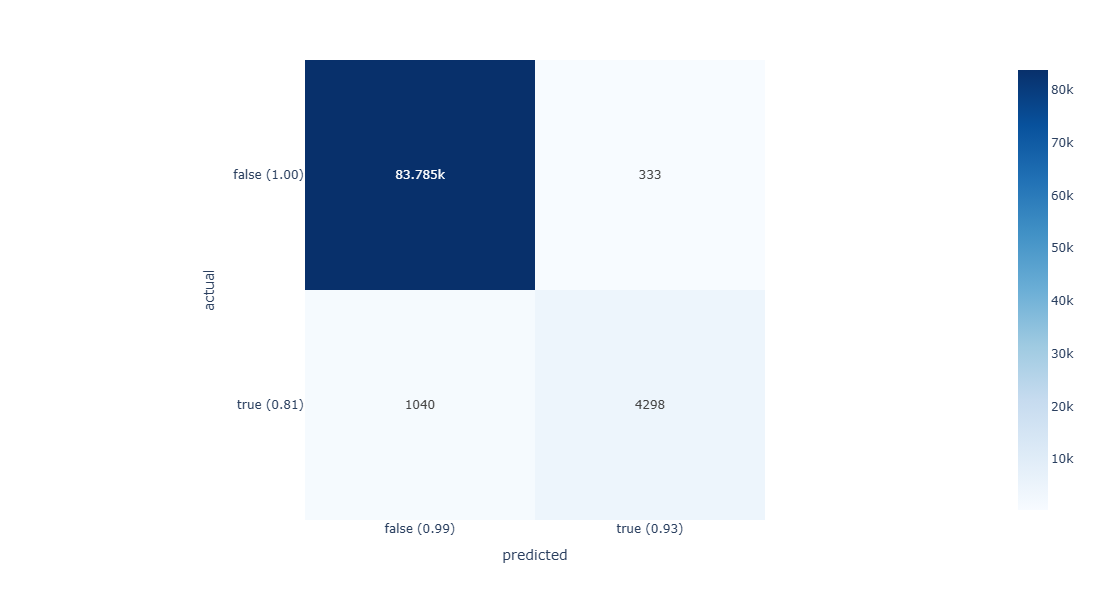

In [25]:
cm = confusion_matrix(y_test, y_pred)#
print(cm)

PX.displayConfusionMatrix(cm, xaxes={'labels': labels, 'title': 'predicted'}, yaxes={'labels': labels, 'title': 'actual'})

#

Die Darstellung der Ergebnisse der Vorhersage durch ein Klassifikationsmodell kann in Form der Confusion-Matrix erfolgen. Dabei werden die Vorhersagen in vier Gruppen unterteilt. True-Positive (TP), richtig vorhergesagte Positive (P), True-Negative (TN), richtig vorhergesagte Negative (N), False-Positive (FP), Negative als positiv vorhergesagt und False-Negative (FN), Positive als negativ vorhergesagt.

Für die Messung der Genauigkeit der Vorhersage durch den Klassifikator werden in der Arbeit die Metriken Accuracy, Recall und Precision verwendet.

Recall, auch True positive rate (TPR), gibt den Anteil der richtig-positiv Vorhergesagten an der Gesamtzahl der tatsächlich Positiven an. Mit Hilfe der Metrik kann eine Aussage darüber getroffen werden, wie gut die positive Klasse durch das Modell erkannt wird.

$$Recall = \frac{TP}{P}$$

Die Precision, auch Positive predicted value (PPV), gibt den Anteil der richtig Positiven an der Gesamtzahl der positiv Vorhergesagten an. Die Metrik gibt Auskunft über die Genauigkeit der positiven Vorhersagen durch ein Modell.

$$Precision = \frac{TP}{TP + FP}$$

Die Accuracy gibt den Anteil der richtig Positiven und Negativen an der Gesamtzahl aller tatsächlich Positiven und Negativen an.

$$Accuracy = \frac{TP + TN}{P + N}⁠$$

Mit dem gewählten Verfahren XGBoost und der Embedding-Dimension 768 wurde mit dem trainierten Modell bei der Vorhersage für die Test-Daten ein Recall von 0.811 und eine Precision von 0.925 erreicht, woraus sich eine Accuracy von 0.985 ergibt.

#### Feature-Importance

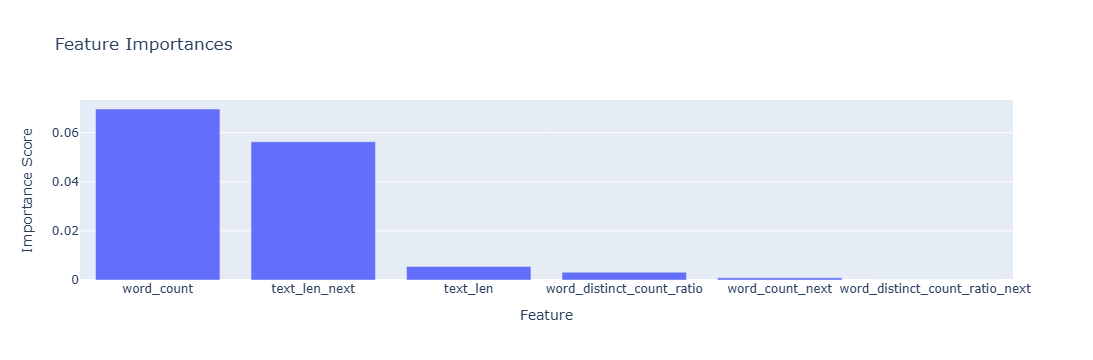

In [26]:
# Feature-Namen aus Preprocessor selektieren
num_features = pipeline.named_steps['preprocessor'].transformers_[0][2][:6]

# Out-of-bag Feature-Importance 
importances = pipeline.named_steps['model'].feature_importances_[:6]

importance_df = pd.DataFrame({
    'Feature': list(num_features),
    'Importance': importances
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Feature-Importance mit plotly visualisieren
fig = px.bar(
    importance_df, 
    x='Feature', 
    y='Importance', 
    title='Feature Importances',
    labels={'Importance': 'Importance Score', 'Feature': 'Feature'}
)

fig.show()

## Hyperparameter-Optimierung

In Abhängigkeit vom verwendetem Verfahren, stehen verschiedene Parameter zur Verfügung, welche das Training eines Modells beeinflussen, wie die Anzahl der zu trainierenden Bäume und deren maximale Tiefe bei Random Forest oder XGBoost.

Mit Hilfe der Hyperparameter-Optimierung wird versucht die bestmöglichen Parameter für das Training eines Modells zu ermitteln, für dessen Vorhersagen der Fehler am geringsten ist. Hierfür stehen verschiedene Verfahren wie Grid-, Random- und Bayesion-Search zur Verfügung.

Um die Generalisierungsfähigkeit der im Zuge der Hyperparameter-Optimierung trainierten Modelle zu ermittelten, wird für alle Verfahren eine 3-Fold Cross-Validation durchgeführt. Für die Optimierung wird aufgrund der geringen Ressourcen und des hohen Rechenaufwands für die Durchführung der einzelnen Iterationen sowie der Cross-Validation nur die hälfte der gewählten Dokumente für das Training verwendet.

### Datensatz erstellen

In [13]:
# Datensatz erstellen+shuffle
df = DatasetProcessor.dataset_create(
    config.dataset['path'], 
    pdf_urls_select.sample(n=round(pdf_urls_select.shape[0] / 2), axis=0, random_state=42),
    embedding_dimension=384
)#.sample(frac=1, axis=0, random_state=42)

2404.11222v2
2408.15983v3
2501.00235v2
2411.04115v2
2404.17763v2
2412.19301v1
2408.08794v2
2410.13267v2
2412.16269v1
2412.14704v2
2412.18405v1
2411.15684v3
2411.16366v2
2404.18869v2
2411.00713v1
2407.04588v2
2410.03667v5
2408.10501v2
2411.11853v3
2411.06721v2
2410.12866v2
2410.13828v2
2405.14149v2
2407.14651v3
2407.08069v2
2410.02846v1
2412.02856v3
2408.10293v2
2409.08596v2
2411.04321v1
2401.05851v4
2411.13951v4
2410.14841v1
2408.09344v2
2404.18775v4
2411.14471v1
2412.13892v2
2406.06594v2
2403.16980v4
2406.10612v1
2410.09568v2
2409.04448v3
2412.06845v4
2402.07810v2
2401.03345v2
2402.02455v2
2410.10304v2
2409.06325v3
2410.02645v1
2409.19835v2
2405.02054v2
2412.00505v2
2408.13919v4
2403.18980v3
2412.09393v2
2407.21067v2
2412.12919v2
2403.05887v2
2412.15191v2
2404.16880v3
2410.00978v2
2407.20090v2
2412.02269v2
2404.08816v5
2412.00566v2
2411.06785v2
2411.02951v2
2411.05601v2
2406.04259v2
2410.20081v3
2407.02994v3
2412.00233v1
2410.05898v7
2405.20823v2
2404.09730v3
2405.12292v3
2410.11843v5

In [14]:
# Train-/Test-Set
X_train, X_test, y_train, y_test = DatasetProcessor.dataset_split(df.drop(columns=['boundary']), df['boundary'], fraction_test=0.2, seed=42)
#X_train, X_eval, y_train, y_eval = DatasetProcessor.dataset_split(X_train, y_train, fraction_test=0.2, seed=42)

In [15]:
del df

#### Bayesian search

In [16]:
# Parameter-Grid für Hyperparameter-Optimierung XGBoost

search_space = {
    'model__n_estimators': Integer(100, 1500),
    'model__max_depth': Integer(2, 12),#Categorical([None] + list(range(1, 31, 5))),#
    #'model__max_leaves':Integer(0, 100),
    'model__min_child_weight': Integer(1, 20),
    'model__max_bin': Integer(128, 320),#128, 384#192,320
    'model__learning_rate': Real(0.01, 0.4, prior="log-uniform"),# Default 0.3
    'model__gamma': Real(0, 10),
    'model__reg_alpha': Real(1e-8, 10, prior="log-uniform"),
    'model__reg_lambda': Real(0.1, 20, prior="log-uniform"),
    'model__subsample': Real(0.5, 1.0),
    'model__colsample_bytree': Real(0.5, 1.0)
}

In [ ]:
# BayesSearchCV initialisieren
bayes_search = BayesSearchCV(
    pipeline,
    search_spaces=search_space,
    n_iter=80,
    scoring='accuracy',  #recall
    cv=3,
    n_jobs=1,
    pre_dispatch=1,
    verbose=1,
    random_state=42
)

bayes_search.fit(X_train, y_train)

Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits


In [29]:
# Bestes Modell wählen
best_model = bayes_search.best_estimator_

# Vorhersage mit bestem Modell durchführen
y_pred = best_model.predict(X_test)

# Berechnung des Recall für Vorhersagen
accuracy = accuracy_score(y_test, y_pred)

print(f'Beste Parameter: {bayes_search.best_params_}')
print(f'accuracy auf Testdaten: {accuracy:.4f}')

Beste Parameter: OrderedDict([('model__colsample_bytree', 0.7408501822463363), ('model__gamma', 0.0), ('model__learning_rate', 0.02818149739725395), ('model__max_bin', 299), ('model__max_depth', 8), ('model__min_child_weight', 17), ('model__n_estimators', 1202), ('model__reg_alpha', 0.5730185808203719), ('model__reg_lambda', 17.29997633137259), ('model__subsample', 0.560329281023299)])
accuracy auf Testdaten: 0.9840


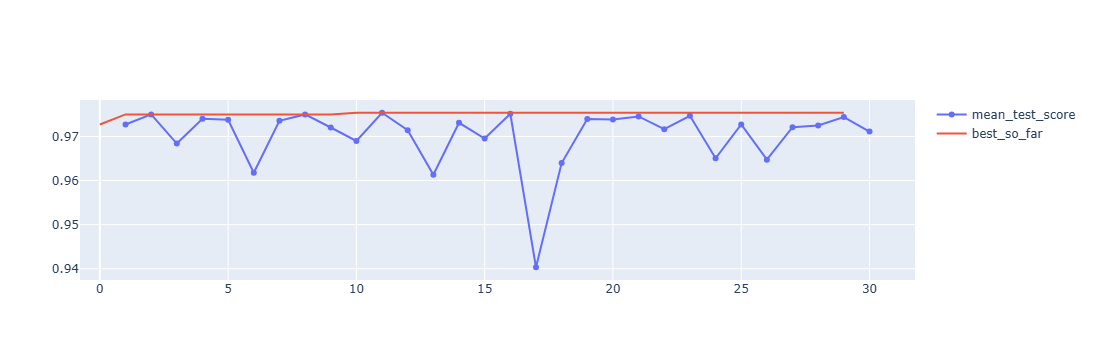

In [20]:
displayHPOResults(bayes_search)

### Confusion Matrix

[[474   4]
 [ 24   9]]


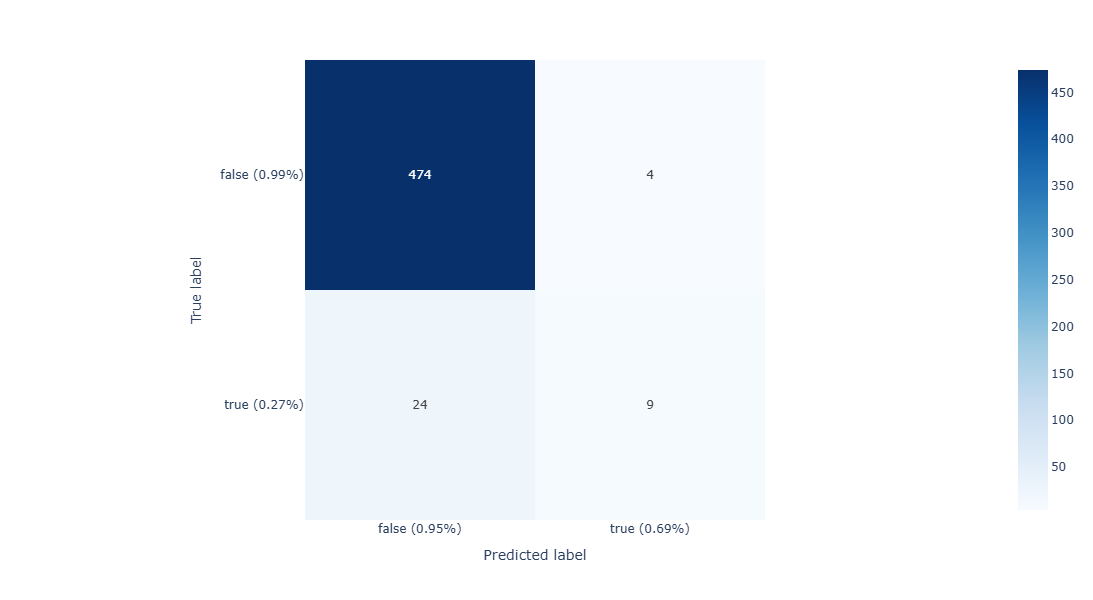

In [142]:
cm = confusion_matrix(y_test, y_pred)#
print(cm)

displayConfusionMatrix(cm)